# Speed Controller Tuning
Autor: Lucía Benjumeda Maldonado

**Robot:**
-   $M=1.5 kg$
-   $b=0.8 N\cdot s/m$ 
-   $\beta =0.7 N\cdot m\cdot s/rad$
-   $WB=0.25 m$ 

**Controller:** Two independent PI channels — linear (v) and angular (ω)  
**Saturation:** 
-   $F_max = 20 N$, 
-   $T_max = 10 N\cdot m$

Tuning strategy:
1. **Kp sweep** with Ki=0 — understand the proportional effect, choose Kp
2. **Ki sweep** with the chosen Kp — eliminate steady-state error, choose Ki

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

from lib.data.dataplot import *
from lib.utils.time import *
from src.robot import RobotModel
from src.controllers import SpeedController

# ── Robot physical parameters ──────────────────────────────────────────────
M    = 1.5
r    = 0.14
b    = 0.8
beta = 0.7
WB   = 0.25

F_MAX = 20.0   # N
T_MAX = 10.0   # N·m

DT    = 0.01   # s
T_SIM = 5.0    # s

V_REF = 1.0    # m/s
W_REF = 3.14   # rad/s

## Simulation helper

In [ ]:
def simulate_speed_step(kp_v, ki_v, kp_w, ki_w, v_ref=V_REF, w_ref=W_REF, duration=T_SIM):
    """
    Simulate one step response and return (time, v, w, v_ref, w_ref).
    """
    cart = RobotModel(M, r, b, beta, WB)
    ctrl = SpeedController(cart, kp_v, ki_v, F_MAX, kp_w, ki_w, T_MAX)

    time_data, v_data, w_data = [], [], []

    t = Time(use_fake_time=True)
    t.start()

    while t.get() < duration:
        t.sleep(DT)
        delta_t = t.elapsed()

        (f_right, f_left) = ctrl.evaluate(delta_t, v_ref, w_ref)
        cart.evaluate(delta_t, f_right, f_left)

        time_data.append(t.get())
        (v, w) = cart.get_speed()
        v_data.append(v)
        w_data.append(w)

    return time_data, v_data, w_data, v_ref, w_ref

---
## 1. Kp sweep (Ki = 0)

P-only control: we vary Kp to understand the proportional effect.

### Lineal Speed:

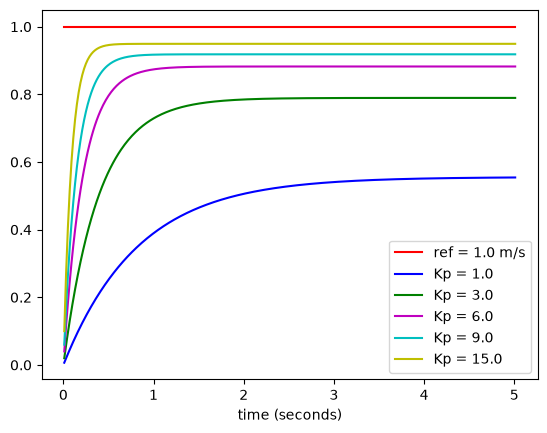

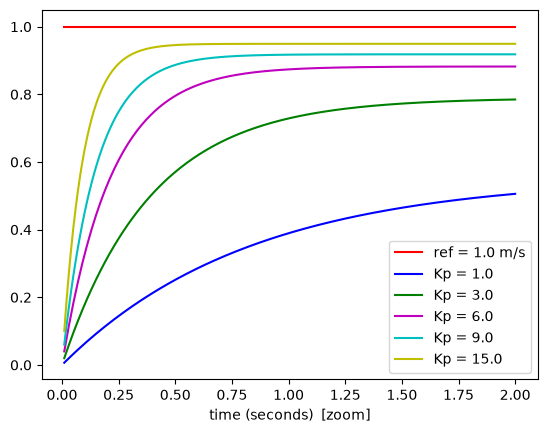

In [ ]:
%matplotlib inline

kp_sweep = [1.0, 3.0, 6.0, 9.0, 15.0]
colors   = ['#891e8b', '#25117f', '#00b0f0', '#70ad47', '#ffc000']

# ── Full view ──────────────────────────────────────────────────────────────
dp = DataPlotter()
dp.set_x('time (seconds)')
dp.add_y('ref', f'ref = {V_REF} m/s')

for kp in kp_sweep:
    dp.add_y(f'kp={kp}', f'Kp = {kp}')

t_data, _, _, v_ref, _ = simulate_speed_step(kp_v=kp_sweep[0], ki_v=0.0,
                                              kp_w=1.0,          ki_w=0.0)
for val in t_data:
    dp.append_x(val)
    dp.append_y('ref', v_ref)

for kp in kp_sweep:
    t_data, v_data, _, _, _ = simulate_speed_step(kp_v=kp, ki_v=0.0,
                                                   kp_w=1.0, ki_w=0.0)
    for v in v_data:
        dp.append_y(f'kp={kp}', v)

dp.plot()

# ── Zoom view (first 1 s) ──────────────────────────────────────────────────
zoom_end = 2.0
idx = next(i for i, t in enumerate(t_data) if t >= zoom_end)

dp_zoom = DataPlotter()
dp_zoom.set_x('time (seconds)  [zoom]')
dp_zoom.add_y('ref', f'ref = {V_REF} m/s')

for kp in kp_sweep:
    dp_zoom.add_y(f'kp={kp}', f'Kp = {kp}')

t_data, _, _, v_ref, _ = simulate_speed_step(kp_v=kp_sweep[0], ki_v=0.0,
                                              kp_w=1.0,          ki_w=0.0)
for val in t_data[:idx]:
    dp_zoom.append_x(val)
    dp_zoom.append_y('ref', v_ref)

for kp in kp_sweep:
    t_data, v_data, _, _, _ = simulate_speed_step(kp_v=kp, ki_v=0.0,
                                                   kp_w=1.0, ki_w=0.0)
    for v in v_data[:idx]:
        dp_zoom.append_y(f'kp={kp}', v)

dp_zoom.plot()

Angular

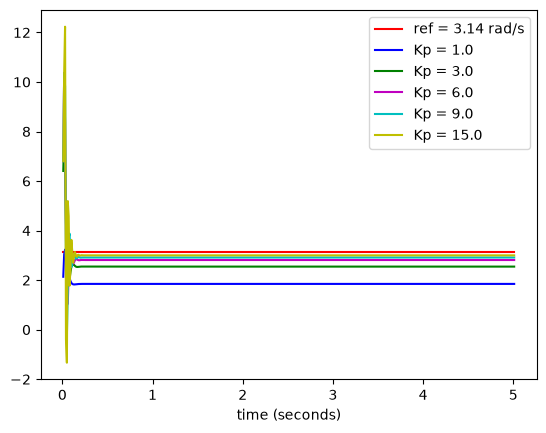

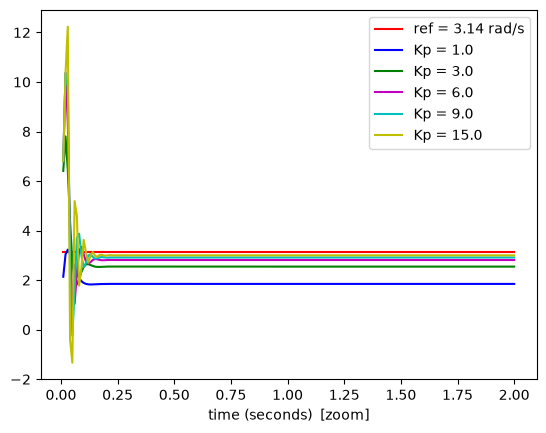

In [ ]:
%matplotlib inline

# ── Full view ──────────────────────────────────────────────────────────────
dp_w = DataPlotter()
dp_w.set_x('time (seconds)')
dp_w.add_y('ref', f'ref = {W_REF} rad/s')

for kp in kp_sweep:
    dp_w.add_y(f'kp={kp}', f'Kp = {kp}')

t_data, _, _, _, w_ref = simulate_speed_step(kp_v=1.0, ki_v=0.0,
                                              kp_w=kp_sweep[0], ki_w=0.0)
for val in t_data:
    dp_w.append_x(val)
    dp_w.append_y('ref', w_ref)

for kp in kp_sweep:
    t_data, _, w_data, _, _ = simulate_speed_step(kp_v=1.0, ki_v=0.0,
                                                   kp_w=kp, ki_w=0.0)
    for w in w_data:
        dp_w.append_y(f'kp={kp}', w)

dp_w.plot()

# ── Zoom view (first 1 s) ──────────────────────────────────────────────────
idx = next(i for i, t in enumerate(t_data) if t >= zoom_end)

dp_zoom_w = DataPlotter()
dp_zoom_w.set_x('time (seconds)  [zoom]')
dp_zoom_w.add_y('ref', f'ref = {W_REF} rad/s')

for kp in kp_sweep:
    dp_zoom_w.add_y(f'kp={kp}', f'Kp = {kp}')

t_data, _, _, _, w_ref = simulate_speed_step(kp_v=1.0, ki_v=0.0,
                                              kp_w=kp_sweep[0], ki_w=0.0)
for val in t_data[:idx]:
    dp_zoom_w.append_x(val)
    dp_zoom_w.append_y('ref', w_ref)

for kp in kp_sweep:
    t_data, _, w_data, _, _ = simulate_speed_step(kp_v=1.0, ki_v=0.0,
                                                   kp_w=kp, ki_w=0.0)
    for w in w_data[:idx]:
        dp_zoom_w.append_y(f'kp={kp}', w)

dp_zoom_w.plot()

Neither reach the target because a ki is needed.

---
## 2. Ki sweep  (with chosen Kp)

Set the Kp values chosen from the sweep above, then vary Ki to eliminate steady-state error.

In [ ]:
# Set K_p chosen values
KP_V_CHOSEN = 9.0 
KP_W_CHOSEN = 3.0

### Linear

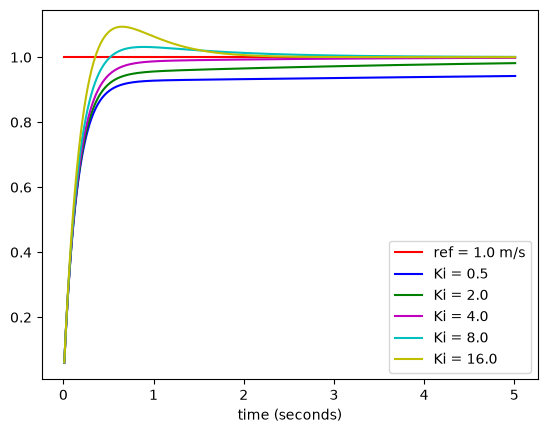

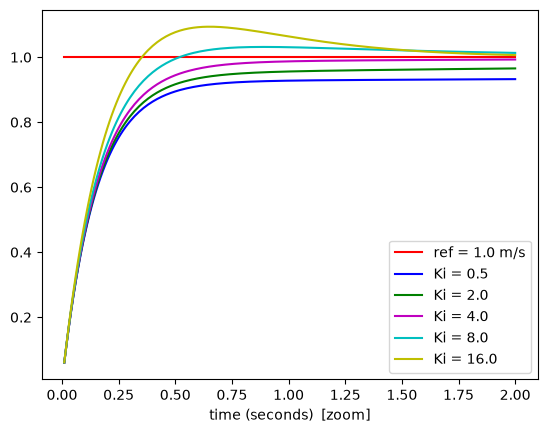

In [ ]:
%matplotlib inline

ki_sweep_l = [0.5, 2.0, 4.0, 8.0, 16.0]
colors   = ["#891e8b", "#25117f", '#00b0f0', '#70ad47', '#ffc000']

# ── Full view ──────────────────────────────────────────────────────────────
dp_ki = DataPlotter()
dp_ki.set_x('time (seconds)')
dp_ki.add_y('ref', f'ref = {V_REF} m/s')

for ki in ki_sweep_l:
    dp_ki.add_y(f'ki={ki}', f'Ki = {ki}')

t_data, _, _, v_ref, _ = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=ki_sweep_l[0],
                                              kp_w=KP_W_CHOSEN, ki_w=0.0)
for val in t_data:
    dp_ki.append_x(val)
    dp_ki.append_y('ref', v_ref)

for ki in ki_sweep_l:
    t_data, v_data, _, _, _ = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=ki,
                                                   kp_w=KP_W_CHOSEN, ki_w=0.0)
    for v in v_data:
        dp_ki.append_y(f'ki={ki}', v)

dp_ki.plot()

# ── Zoom view (first 1 s) ──────────────────────────────────────────────────
idx = next(i for i, t in enumerate(t_data) if t >= zoom_end)

dp_ki_zoom = DataPlotter()
dp_ki_zoom.set_x('time (seconds)  [zoom]')
dp_ki_zoom.add_y('ref', f'ref = {V_REF} m/s')

for ki in ki_sweep_l:
    dp_ki_zoom.add_y(f'ki={ki}', f'Ki = {ki}')

t_data, _, _, v_ref, _ = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=ki_sweep_l[0],
                                              kp_w=KP_W_CHOSEN, ki_w=0.0)
for val in t_data[:idx]:
    dp_ki_zoom.append_x(val)
    dp_ki_zoom.append_y('ref', v_ref)

for ki in ki_sweep_l:
    t_data, v_data, _, _, _ = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=ki,
                                                   kp_w=KP_W_CHOSEN, ki_w=0.0)
    for v in v_data[:idx]:
        dp_ki_zoom.append_y(f'ki={ki}', v)

dp_ki_zoom.plot()

### Angular

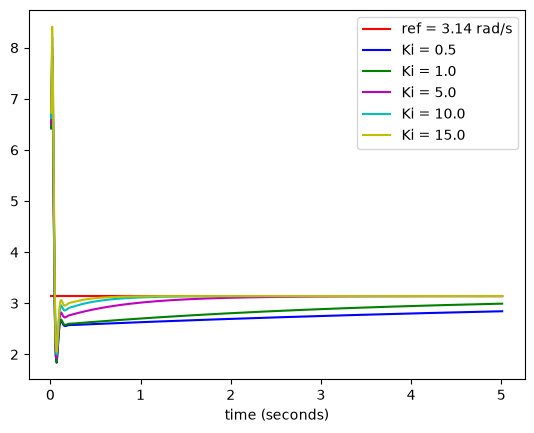

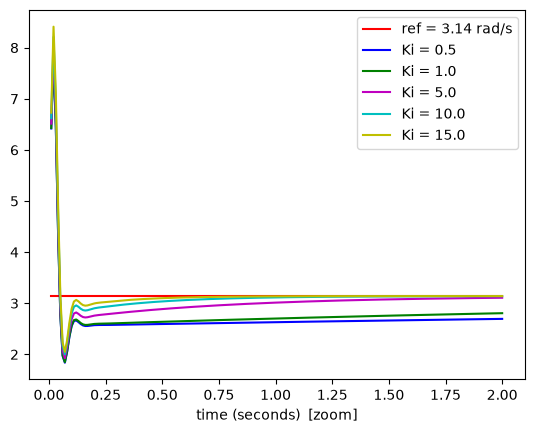

In [ ]:
ki_sweep_w = [0.5, 1.0, 5.0, 10.0, 15.0]
colors   = ["#891e8b", "#25117f", '#00b0f0', '#70ad47', '#ffc000']

# ── Full view ──────────────────────────────────────────────────────────────
dp_ki_w = DataPlotter()
dp_ki_w.set_x('time (seconds)')
dp_ki_w.add_y('ref', f'ref = {W_REF} rad/s')

for ki in ki_sweep_w:
    dp_ki_w.add_y(f'ki={ki}', f'Ki = {ki}')

t_data, _, _, _, w_ref = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=0.0,
                                              kp_w=KP_W_CHOSEN, ki_w=ki_sweep_w[0])
for val in t_data:
    dp_ki_w.append_x(val)
    dp_ki_w.append_y('ref', w_ref)

for ki in ki_sweep_w:
    t_data, _, w_data, _, _ = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=0.0,
                                                   kp_w=KP_W_CHOSEN, ki_w=ki)
    for w in w_data:
        dp_ki_w.append_y(f'ki={ki}', w)

dp_ki_w.plot()

# ── Zoom view (first 1 s) ──────────────────────────────────────────────────
idx = next(i for i, t in enumerate(t_data) if t >= zoom_end)

dp_ki_zoom_w = DataPlotter()
dp_ki_zoom_w.set_x('time (seconds)  [zoom]')
dp_ki_zoom_w.add_y('ref', f'ref = {W_REF} rad/s')

for ki in ki_sweep_w:
    dp_ki_zoom_w.add_y(f'ki={ki}', f'Ki = {ki}')

t_data, _, _, _, w_ref = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=0.0,
                                              kp_w=KP_W_CHOSEN, ki_w=ki_sweep_w[0])
for val in t_data[:idx]:
    dp_ki_zoom_w.append_x(val)
    dp_ki_zoom_w.append_y('ref', w_ref)

for ki in ki_sweep_w:
    t_data, _, w_data, _, _ = simulate_speed_step(kp_v=KP_V_CHOSEN, ki_v=0.0,
                                                   kp_w=KP_W_CHOSEN, ki_w=ki)
    for w in w_data[:idx]:
        dp_ki_zoom_w.append_y(f'ki={ki}', w)

dp_ki_zoom_w.plot()

---
## Summary — Chosen gains

| Channel | Kp | Ki |
|---|---|---|
| Linear (v) | **9.0** | **4.0** |
| Angular (ω) | **3.0** | **15.0** |

Used in `src/python/controllers.py`:
```python
speed_ctrl = SpeedControl2D(9.0, 4.0, 20.0, 3.0, 15.0, 10.0)
```
